# A Comprehensive Guide to Tokenizers
Authors:  
 - [Lior Gazit](https://www.linkedin.com/in/liorgazit).  
 - [Meysam Ghaffari](https://www.linkedin.com/in/meysam-ghaffari-ph-d-a2553088/).  

This Colab notebook is referenced in our book's Github repo:   
https://github.com/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition   
<a target="_blank" href="https://colab.research.google.com/github/PacktPublishing/Mastering-NLP-From-Foundations-to-Agents-Second-Edition/blob/main/Chapter4_notebooks/Ch4_Tokenizers_Comprehensive.ipynb">
  <img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/>
</a>


This notebook is taught and reviewed in our book:  
**[Mastering NLP from Foundations to Agents](https://www.amazon.com/Mastering-NLP-Foundations-Agents-Automation/dp/1806106132)**  
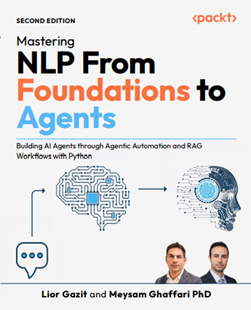



**The purpose of this notebook:**  
Tokenization is the **first and most critical step** in any NLP pipeline. Before a model can process language, it must convert raw text into discrete units, *tokens*.
Tokens are numerical IDs.  

This notebook walks through **every major tokenization strategy**, building intuition from first principles before moving to modern pre-trained tokenizers used in BERT, GPT-2, LLaMA, and T5.

### What it covers:  

| # | Section | Strategy |
|---|---------|----------|
| 1 | Setup & Fundamentals | Installation, core concepts |
| 2 | Character-Level Tokenization | Split on every character |
| 3 | Whitespace / Word-Level Tokenization | Split on spaces |
| 4 | Custom Vocabulary Tokenizer | Hand-crafted vocab with HuggingFace |
| 5 | Byte Pair Encoding (BPE) | GPT-2 style subword tokenization |
| 6 | WordPiece Tokenization | BERT-style subword tokenization |
| 7 | Unigram Language Model | SentencePiece / T5 style |
| 8 | Pre-trained Tokenizers | BERT, GPT-2, T5, LLaMA |
| 9 | Side-by-Side Comparison | All methods on the same text |
| 10 | Tokenizer Quirks & Gotchas | Edge cases every practitioner must know |


**Requirements:**  
* When running in Colab, use this runtime notebook setting: `Python 3, CPU`   
* When running in Colab, Run the first cell to install all dependencies, then restart the runtime before continuing.  

>*```Disclaimer: The content and ideas presented in this notebook are solely those of the authors and do not represent the views or intellectual property of the authors' employers.```*

Install:

In [1]:
# REMARK:
# If the below code error's out due to a Python package discrepency, it may be because new versions are causing it.
# In which case, set "default_installations" to False to revert to the original image:
import subprocess, sys

default_installations = True
if default_installations:
  packages = [
    "tokenizers",          # HuggingFace low-level tokenizer library
    "transformers",        # HuggingFace Transformers (pre-trained tokenizers)
    "sentencepiece",       # Google SentencePiece (Unigram / BPE)
    "datasets",            # HuggingFace Datasets (for training corpora)
    "matplotlib",          # Visualizations
    "pandas",              # Comparison tables
    "rich",                # Pretty terminal output
  ]
  for pkg in packages:
    subprocess.check_call([sys.executable, "-m", "pip", "install", pkg, "-q"])

  print("✅ All packages installed.")
  print("⚠️  If running in Colab, go to Runtime → Restart Runtime, then re-run from Cell 1-B onward.")
else:
  print("<place holder>")
    # >> HAVE CODE THAT INSTALLS PRESCRIBED LIBRARIES




✅ All packages installed.
⚠️  If running in Colab, go to Runtime → Restart Runtime, then re-run from Cell 1-B onward.


Imports:

In [2]:
import os, json, re, warnings
warnings.filterwarnings("ignore")

import pandas as pd
import matplotlib.pyplot as plt
import matplotlib.patches as mpatches
import matplotlib.colors as mcolors

# HuggingFace tokenizer building blocks
from tokenizers import Tokenizer, AddedToken
from tokenizers.models import WordLevel, BPE, WordPiece, Unigram
from tokenizers.pre_tokenizers import Whitespace, ByteLevel, Metaspace, CharDelimiterSplit
from tokenizers.trainers import BpeTrainer, WordPieceTrainer, UnigramTrainer, WordLevelTrainer
from tokenizers.processors import TemplateProcessing
from tokenizers.normalizers import NFD, Lowercase, StripAccents, Sequence as NormSequence
from tokenizers.decoders import ByteLevel as ByteLevelDecoder, WordPiece as WordPieceDecoder
from transformers import PreTrainedTokenizerFast, AutoTokenizer

### Shared helper utilities used throughout notebook


In [3]:
# ── ANSI colour helpers (Colab + terminal compatible) ────────
COLORS = [
    "\033[48;5;226m",  # yellow
    "\033[48;5;123m",  # cyan
    "\033[48;5;214m",  # orange
    "\033[48;5;156m",  # green
    "\033[48;5;213m",  # pink
    "\033[48;5;153m",  # blue
]
RESET = "\033[0m"

def colorize_tokens(tokens):
    """Print tokens with alternating background colours for easy visual parsing."""
    rendered = ""
    for i, tok in enumerate(tokens):
        color = COLORS[i % len(COLORS)]
        rendered += f"{color} {tok} {RESET}"
    print(rendered)

def show_encoding(text, tokenizer, label="Tokenizer"):
    """Unified display: tokens, IDs, and token count for any HF tokenizer."""
    enc = tokenizer(text)
    ids = enc["input_ids"]
    tokens = tokenizer.convert_ids_to_tokens(ids)

    print(f"\n{'─'*60}")
    print(f"  🏷️  {label}")
    print(f"{'─'*60}")
    print(f"  Input : {repr(text)}")
    print(f"  Tokens: {tokens}")
    print(f"  IDs   : {ids}")
    print(f"  Count : {len(ids)} tokens")
    print(f"{'─'*60}")
    colorize_tokens(tokens)
    return tokens, ids

def show_encoding_raw(text, tokenizer_obj, label="Tokenizer"):
    """Same but for raw tokenizers.Tokenizer objects (non-HF-wrapped)."""
    enc = tokenizer_obj.encode(text)
    tokens = enc.tokens
    ids = enc.ids

    print(f"\n{'─'*60}")
    print(f"  🏷️  {label}")
    print(f"{'─'*60}")
    print(f"  Input : {repr(text)}")
    print(f"  Tokens: {tokens}")
    print(f"  IDs   : {ids}")
    print(f"  Count : {len(ids)} tokens")
    print(f"{'─'*60}")
    colorize_tokens(tokens)
    return tokens, ids

def token_bar_chart(results_dict, title="Token Count Comparison"):
    """Bar chart comparing how many tokens each tokenizer produces for the same input."""
    names = list(results_dict.keys())
    counts = [results_dict[n] for n in names]
    palette = list(mcolors.TABLEAU_COLORS.values())[:len(names)]

    fig, ax = plt.subplots(figsize=(10, 4))
    bars = ax.barh(names, counts, color=palette, edgecolor="black", linewidth=0.5)
    ax.bar_label(bars, padding=4, fontsize=11)
    ax.set_xlabel("Number of tokens", fontsize=12)
    ax.set_title(title, fontsize=14, fontweight="bold")
    ax.invert_yaxis()
    ax.set_xlim(0, max(counts) * 1.18)
    plt.tight_layout()
    plt.show()

# ── Sample sentences used throughout the notebook ───────────
SAMPLE_TEXT   = "The quick brown fox jumps over the lazy dog."
SAMPLE_LONG   = "Tokenization is the process of splitting raw text into smaller units called tokens, which neural networks can process."
SAMPLE_OOV    = "The antiestablishmentarianism of the supercalifragilisticexpialidocious phenomenon is unparalleled."
SAMPLE_CODE   = "def fibonacci(n): return n if n <= 1 else fibonacci(n-1) + fibonacci(n-2)"
SAMPLE_MULTI  = "Hello! Bonjour! こんにちは! مرحبا! 你好!"

print(f"\nSample sentences ready:")
for name, text in [("SAMPLE_TEXT",SAMPLE_TEXT),("SAMPLE_LONG",SAMPLE_LONG),
                   ("SAMPLE_OOV",SAMPLE_OOV),("SAMPLE_CODE",SAMPLE_CODE),("SAMPLE_MULTI",SAMPLE_MULTI)]:
    print(f"  {name}: {text[:60]}{'...' if len(text)>60 else ''}")


Sample sentences ready:
  SAMPLE_TEXT: The quick brown fox jumps over the lazy dog.
  SAMPLE_LONG: Tokenization is the process of splitting raw text into small...
  SAMPLE_OOV: The antiestablishmentarianism of the supercalifragilisticexp...
  SAMPLE_CODE: def fibonacci(n): return n if n <= 1 else fibonacci(n-1) + f...
  SAMPLE_MULTI: Hello! Bonjour! こんにちは! مرحبا! 你好!


## Character-Level Tokenization

The simplest possible tokenizer: **every character is one token**.

- ✅ Zero out-of-vocabulary (OOV) problem - any text can be tokenized
- ✅ Tiny vocabulary size (≈ 256 for ASCII, ~100k for full Unicode)
- ❌ Sequences become very long, making attention in Transformers expensive
- ❌ Individual characters carry little semantic meaning

> **Used in:** Early character-level RNN language models (Karpathy's *char-rnn*), some speech-to-text systems.

### Character tokenizer - pure Python implementation

In [4]:
class CharacterTokenizer:
    """
    A minimal character-level tokenizer built from scratch.
    Demonstrates the core vocabulary-building and encode/decode loop
    without any library dependencies.
    """

    def __init__(self, corpus: list[str], special_tokens=None):
        if special_tokens is None:
            special_tokens = ["<pad>", "<unk>", "<bos>", "<eos>"]

        # 1. Collect all unique characters from the training corpus
        chars = sorted(set("".join(corpus)))

        # 2. Build vocabulary: special tokens first, then regular chars
        all_tokens = special_tokens + chars
        self.token2id = {tok: i for i, tok in enumerate(all_tokens)}
        self.id2token = {i: tok for tok, i in self.token2id.items()}

        # 3. Shorthand IDs
        self.pad_id = self.token2id["<pad>"]
        self.unk_id = self.token2id["<unk>"]
        self.bos_id = self.token2id["<bos>"]
        self.eos_id = self.token2id["<eos>"]

    @property
    def vocab_size(self):
        return len(self.token2id)

    def encode(self, text: str, add_special_tokens=True) -> list[int]:
        ids = [self.token2id.get(ch, self.unk_id) for ch in text]
        if add_special_tokens:
            ids = [self.bos_id] + ids + [self.eos_id]
        return ids

    def decode(self, ids: list[int], skip_special_tokens=True) -> str:
        special = {self.pad_id, self.unk_id, self.bos_id, self.eos_id}
        return "".join(
            self.id2token[i] for i in ids
            if not (skip_special_tokens and i in special)
        )

    def tokenize(self, text: str) -> list[str]:
        return ["<bos>"] + list(text) + ["<eos>"]


# ── Train on a small corpus ──────────────────────────────────
training_corpus = [
    SAMPLE_TEXT,
    SAMPLE_LONG,
    "Hello, World! This is a character-level tokenizer."
]

char_tok = CharacterTokenizer(training_corpus)
print(f"Vocabulary size : {char_tok.vocab_size}")
print(f"First 20 tokens : {list(char_tok.token2id.keys())[:20]}")

Vocabulary size : 38
First 20 tokens : ['<pad>', '<unk>', '<bos>', '<eos>', ' ', '!', ',', '-', '.', 'H', 'T', 'W', 'a', 'b', 'c', 'd', 'e', 'f', 'g', 'h']


### Encode, decode, and visualise character tokens

In [5]:
text = "Hello, World!"
tokens  = char_tok.tokenize(text)
ids     = char_tok.encode(text)
decoded = char_tok.decode(ids)

print("═" * 55)
print("  CHARACTER-LEVEL TOKENIZER")
print("═" * 55)
print(f"  Input  : {repr(text)}")
print(f"  Tokens : {tokens}")
print(f"  IDs    : {ids}")
print(f"  Count  : {len(ids)} tokens  (note: very long!)")
print(f"  Decode : {repr(decoded)}")
print("═" * 55)
colorize_tokens(tokens)

═══════════════════════════════════════════════════════
  CHARACTER-LEVEL TOKENIZER
═══════════════════════════════════════════════════════
  Input  : 'Hello, World!'
  Tokens : ['<bos>', 'H', 'e', 'l', 'l', 'o', ',', ' ', 'W', 'o', 'r', 'l', 'd', '!', '<eos>']
  IDs    : [2, 9, 16, 23, 23, 26, 6, 4, 11, 26, 29, 23, 15, 5, 3]
  Count  : 15 tokens  (note: very long!)
  Decode : 'Hello, World!'
═══════════════════════════════════════════════════════
 <bos>  H  e  l  l  o  ,     W  o  r  l  d  !  <eos> 


### OOV handling in character tokenizers
Characters not seen during training map to <unk>.  
In practice, this is rare for char-level tokenizers since
every individual character can be in the vocab.

In [6]:
oov_text = "HELLO 123 🎉"
tokens_oov = char_tok.tokenize(oov_text)
ids_oov    = char_tok.encode(oov_text)

print(f"Text   : {repr(oov_text)}")
print(f"Tokens : {tokens_oov}")
print(f"IDs    : {ids_oov}")
print()
print("⚠️  Characters not in the training corpus (like '🎉') become <unk>.")
colorize_tokens(tokens_oov)

Text   : 'HELLO 123 🎉'
Tokens : ['<bos>', 'H', 'E', 'L', 'L', 'O', ' ', '1', '2', '3', ' ', '🎉', '<eos>']
IDs    : [2, 9, 1, 1, 1, 1, 4, 1, 1, 1, 4, 1, 3]

⚠️  Characters not in the training corpus (like '🎉') become <unk>.
 <bos>  H  E  L  L  O     1  2  3     🎉  <eos> 


### Visualise sequence length vs. word count


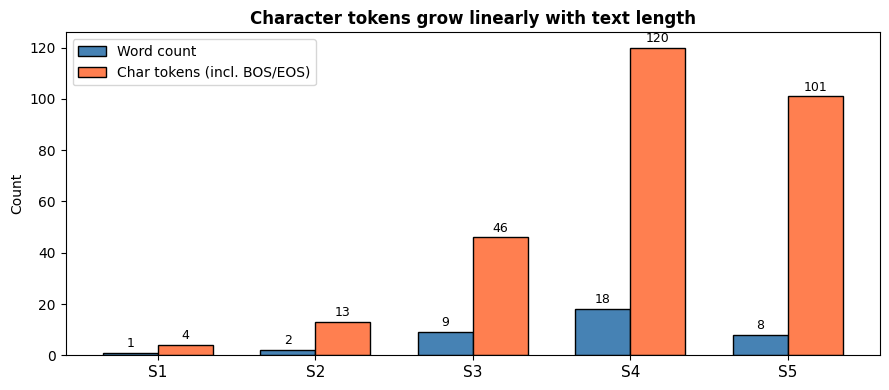

S1–S5 are progressively longer sentences.


In [7]:
sentences = [
    "Hi", "Hello World", SAMPLE_TEXT, SAMPLE_LONG, SAMPLE_OOV
]

word_counts = [len(s.split()) for s in sentences]
char_counts = [len(char_tok.encode(s)) for s in sentences]

fig, ax = plt.subplots(figsize=(9, 4))
x = range(len(sentences))
width = 0.35
b1 = ax.bar([i - width/2 for i in x], word_counts, width, label="Word count", color="steelblue", edgecolor="black")
b2 = ax.bar([i + width/2 for i in x], char_counts,  width, label="Char tokens (incl. BOS/EOS)", color="coral",    edgecolor="black")
ax.set_xticks(list(x))
ax.set_xticklabels([f"S{i+1}" for i in x], fontsize=11)
ax.set_ylabel("Count")
ax.set_title("Character tokens grow linearly with text length", fontweight="bold")
ax.legend()
ax.bar_label(b1, padding=2, fontsize=9)
ax.bar_label(b2, padding=2, fontsize=9)
plt.tight_layout()
plt.show()
print("S1–S5 are progressively longer sentences.")

## Whitespace / Word-Level Tokenization

Split text on whitespace (and optionally punctuation). Each **word** is one token.

- ✅ Tokens carry full word meaning
- ✅ Short sequences
- ❌ **Vocabulary explosion** - English alone has 170,000+ words
- ❌ Severe OOV problem for rare / unseen words
- ❌ Morphological variants treated as completely different tokens (`run`, `runs`, `running`, `ran`)

> **Used in:** Early NLP (bag-of-words), some simple rule-based systems, `CountVectorizer` in scikit-learn.

### Word-level tokenizer - pure Python


In [8]:
class WordLevelTokenizer:
    """
    A simple whitespace-based word tokenizer.
    Demonstrates vocabulary construction from a corpus and
    the fundamental OOV problem.
    """

    def __init__(self, corpus: list[str], special_tokens=None, lowercase=True):
        if special_tokens is None:
            special_tokens = ["<pad>", "<unk>", "<bos>", "<eos>"]
        self.lowercase = lowercase

        # Build vocabulary from corpus
        word_set = set()
        for sentence in corpus:
            tokens = self._split(sentence)
            word_set.update(tokens)

        self.token2id = {tok: i for i, tok in enumerate(special_tokens)}
        for word in sorted(word_set):
            if word not in self.token2id:
                self.token2id[word] = len(self.token2id)
        self.id2token = {i: tok for tok, i in self.token2id.items()}

        self.pad_id = self.token2id["<pad>"]
        self.unk_id = self.token2id["<unk>"]
        self.bos_id = self.token2id["<bos>"]
        self.eos_id = self.token2id["<eos>"]

    def _split(self, text):
        if self.lowercase:
            text = text.lower()
        # Split on whitespace and keep punctuation separate
        return re.findall(r"\w+|[^\w\s]", text)

    @property
    def vocab_size(self):
        return len(self.token2id)

    def tokenize(self, text):
        return ["<bos>"] + self._split(text) + ["<eos>"]

    def encode(self, text, add_special_tokens=True):
        words = self._split(text)
        ids = [self.token2id.get(w, self.unk_id) for w in words]
        if add_special_tokens:
            ids = [self.bos_id] + ids + [self.eos_id]
        return ids

    def decode(self, ids, skip_special_tokens=True):
        special = {self.pad_id, self.unk_id, self.bos_id, self.eos_id}
        return " ".join(
            self.id2token.get(i, "<unk>") for i in ids
            if not (skip_special_tokens and i in special)
        )


# ── Train on a small corpus ──────────────────────────────────
corpus = [
    "The quick brown fox jumps over the lazy dog",
    "A fox and a dog walked into a bar",
    "Tokenization is the first step in NLP pipelines",
    SAMPLE_TEXT, SAMPLE_LONG,
]

word_tok = WordLevelTokenizer(corpus)
print(f"Vocabulary size : {word_tok.vocab_size}")
print(f"First 15 vocab entries: {list(word_tok.token2id.items())[:15]}")

Vocabulary size : 39
First 15 vocab entries: [('<pad>', 0), ('<unk>', 1), ('<bos>', 2), ('<eos>', 3), (',', 4), ('.', 5), ('a', 6), ('and', 7), ('bar', 8), ('brown', 9), ('called', 10), ('can', 11), ('dog', 12), ('first', 13), ('fox', 14)]


### Encode / decode and observe OOV behaviour

In [9]:
# Known sentence
known = "The quick brown fox jumps over the lazy dog"
tokens_known = word_tok.tokenize(known)
ids_known    = word_tok.encode(known)
print("Known sentence:")
colorize_tokens(tokens_known)
print(f"IDs: {ids_known}\n")

# Sentence with OOV words
oov = "The quick purple cat leaps over the energetic puppy"
tokens_oov = word_tok.tokenize(oov)
ids_oov    = word_tok.encode(oov)
print("OOV sentence (words not in training vocab become <unk>):")
colorize_tokens(tokens_oov)
print(f"IDs: {ids_oov}")
print()
print("⚠️  Notice: 'purple', 'cat', 'leaps', 'energetic', 'puppy' → all map to <unk> (ID=1)")

Known sentence:
 <bos>  the  quick  brown  fox  jumps  over  the  lazy  dog  <eos> 
IDs: [2, 33, 27, 9, 14, 18, 24, 33, 19, 12, 3]

OOV sentence (words not in training vocab become <unk>):
 <bos>  the  quick  purple  cat  leaps  over  the  energetic  puppy  <eos> 
IDs: [2, 33, 27, 1, 1, 1, 24, 33, 1, 1, 3]

⚠️  Notice: 'purple', 'cat', 'leaps', 'energetic', 'puppy' → all map to <unk> (ID=1)


### The morphology problem: related words have completely unrelated IDs

In [10]:
morphology_corpus = [
    "I run every day", "She runs fast", "He is running in the park",
    "They ran yesterday", "The runner won the race",
    "jumping jacks are fun", "she jumped high", "the jump was impressive"
]

morph_tok = WordLevelTokenizer(morphology_corpus)

variants = ["run", "runs", "running", "ran", "runner"]

print("Morphological variants → Token IDs (word-level):")
print(f"{'Word':<15} {'ID':>6}")
print("-" * 22)
for word in variants:
    tok_id = morph_tok.token2id.get(word, morph_tok.unk_id)
    oov_marker = "  ← <unk>" if tok_id == morph_tok.unk_id else ""
    print(f"  {word:<13} {tok_id:>6}{oov_marker}")

print()
print("💡 Each form gets an independent, arbitrary ID.")
print("   Subword tokenizers (BPE, WordPiece) solve this by sharing the root 'run'.")

Morphological variants → Token IDs (word-level):
Word                ID
----------------------
  run               22
  runs              25
  running           24
  ran               21
  runner            23

💡 Each form gets an independent, arbitrary ID.
   Subword tokenizers (BPE, WordPiece) solve this by sharing the root 'run'.


## Custom Vocabulary Tokenizer (HuggingFace)

Here we use the `tokenizers` library to build a **production-grade** word-level tokenizer with a hand-crafted vocabulary, then wrap it with `PreTrainedTokenizerFast` for full Transformers compatibility.

This mirrors the **seed code** from the book and extends it with deeper explanation.

### Build a custom vocabulary tokenizer (HF-style)


In [11]:
# 1. Define your domain-specific tokens
custom_tokens = [
    "hello", "world", "foo", "bar", "baz",
    "cat", "dog", "run", "fast", "slow",
    "nlp", "transformer", "token", "embed", "layer"
]

# 2. Define special tokens
SPECIAL_TOKENS = {
    "unk_token": "<unk>",   # Unknown / OOV
    "pad_token": "<pad>",   # Padding for batch alignment
    "bos_token": "<bos>",   # Beginning of sequence
    "eos_token": "<eos>",   # End of sequence
    "mask_token": "<mask>", # Masked token (for MLM pre-training)
}

# 3. Build unified vocabulary (special tokens get the lowest IDs)
all_tokens = list(SPECIAL_TOKENS.values()) + custom_tokens
vocab = {token: idx for idx, token in enumerate(all_tokens)}

print("Full vocabulary:")
for tok, idx in vocab.items():
    print(f"  {idx:3d} : {tok}")

Full vocabulary:
    0 : <unk>
    1 : <pad>
    2 : <bos>
    3 : <eos>
    4 : <mask>
    5 : hello
    6 : world
    7 : foo
    8 : bar
    9 : baz
   10 : cat
   11 : dog
   12 : run
   13 : fast
   14 : slow
   15 : nlp
   16 : transformer
   17 : token
   18 : embed
   19 : layer


### Assemble the tokenizer from its components
A HuggingFace tokenizer is built from these components:
```  
┌────────────────────────────────────────────────────────┐  
│  Normalizer  → case folding, unicode normalisation     │  
│  Pre-Tokenizer → first split (e.g. on whitespace)      │  
│  Model        → core algorithm (WordLevel/BPE/…)       │  
│  Post-Processor → add [CLS]/[SEP] etc.                 │  
│  Decoder       → convert tokens back to string         │  
└────────────────────────────────────────────────────────┘  
```

In [12]:
# ── Step 1: Core model ───────────────────────────────────────
model = WordLevel(
    vocab=vocab,
    unk_token=SPECIAL_TOKENS["unk_token"]
)

# ── Step 2: Assemble tokenizer ───────────────────────────────
raw_tokenizer = Tokenizer(model)

# ── Step 3: Add pre-tokenizer (split on whitespace) ─────────
raw_tokenizer.pre_tokenizer = Whitespace()

# ── Step 4: Add post-processor (auto-add BOS/EOS) ───────────
raw_tokenizer.post_processor = TemplateProcessing(
    single="<bos> $A <eos>",
    pair="<bos> $A <eos> $B:1 <eos>:1",
    special_tokens=[
        ("<bos>", vocab["<bos>"]),
        ("<eos>", vocab["<eos>"]),
    ]
)

# ── Step 5: Wrap for HuggingFace compatibility ───────────────
hf_custom = PreTrainedTokenizerFast(
    tokenizer_object=raw_tokenizer,
    **SPECIAL_TOKENS  # unpack all special token mappings
)

print("✅ Custom tokenizer built!")
print(f"   Vocab size          : {hf_custom.vocab_size}")
print(f"   Special tokens      : {list(SPECIAL_TOKENS.values())}")
print(f"   unk_token ID        : {hf_custom.unk_token_id}")
print(f"   pad_token ID        : {hf_custom.pad_token_id}")

✅ Custom tokenizer built!
   Vocab size          : 20
   Special tokens      : ['<unk>', '<pad>', '<bos>', '<eos>', '<mask>']
   unk_token ID        : 0
   pad_token ID        : 1


### Encode with the custom tokenizer


In [13]:
# Words in vocab
show_encoding("hello world foo bar", hf_custom, "Custom WordLevel (in-vocab)")

# Mix of known and unknown
show_encoding("hello unknown_word world", hf_custom, "Custom WordLevel (with OOV)")

# Pair encoding (sentence A + sentence B)
enc_pair = hf_custom("hello world", "foo bar baz")
pair_tokens = hf_custom.convert_ids_to_tokens(enc_pair['input_ids'])
print(f"\nPair encoding")
print(f"  Tokens : {pair_tokens}")
print(f"  IDs    : {enc_pair['input_ids']}")

# token_type_ids are only present when the post-processor emits them.
# TemplateProcessing with a pair template does produce them, but
# PreTrainedTokenizerFast only forwards the key when the underlying
# fast tokenizer explicitly returns it.  Always guard with .get().
type_ids = enc_pair.get('token_type_ids')
if type_ids is not None:
    print(f"  Token type IDs : {type_ids}  (0 = sentence A, 1 = sentence B)")
else:
    # Reconstruct manually from BOS/EOS boundaries for illustration
    ids = enc_pair['input_ids']
    bos_id = hf_custom.bos_token_id
    eos_id = hf_custom.eos_token_id
    # Find the first EOS - everything up to and including it is sentence A
    first_eos = next((i for i, x in enumerate(ids) if x == eos_id), len(ids))
    manual_type_ids = [0 if i <= first_eos else 1 for i in range(len(ids))]
    print(f"  Token type IDs : {manual_type_ids}  (reconstructed - 0=A, 1=B)")
    print("  ℹ️  token_type_ids not emitted by this tokenizer's post-processor;")
    print("     use a model that produces them (e.g. BERT) for native support.")


────────────────────────────────────────────────────────────
  🏷️  Custom WordLevel (in-vocab)
────────────────────────────────────────────────────────────
  Input : 'hello world foo bar'
  Tokens: ['<bos>', 'hello', 'world', 'foo', 'bar', '<eos>']
  IDs   : [2, 5, 6, 7, 8, 3]
  Count : 6 tokens
────────────────────────────────────────────────────────────
 <bos>  hello  world  foo  bar  <eos> 

────────────────────────────────────────────────────────────
  🏷️  Custom WordLevel (with OOV)
────────────────────────────────────────────────────────────
  Input : 'hello unknown_word world'
  Tokens: ['<bos>', 'hello', '<unk>', 'world', '<eos>']
  IDs   : [2, 5, 0, 6, 3]
  Count : 5 tokens
────────────────────────────────────────────────────────────
 <bos>  hello  <unk>  world  <eos> 

Pair encoding
  Tokens : ['<bos>', 'hello', 'world', '<eos>', 'foo', 'bar', 'baz', '<eos>']
  IDs    : [2, 5, 6, 3, 7, 8, 9, 3]
  Token type IDs : [0, 0, 0, 0, 1, 1, 1, 1]  (reconstructed - 0=A, 1=B)
  ℹ️  tok

### Save and reload the custom tokenizer

In [14]:
SAVE_DIR = "custom_wordlevel_tokenizer"
hf_custom.save_pretrained(SAVE_DIR)

print(f"✅ Tokenizer saved to '{SAVE_DIR}/'")
print("   Files written:")
for f in os.listdir(SAVE_DIR):
    print(f"     - {f}")

# ── Reload from disk ─────────────────────────────────────────
reloaded = PreTrainedTokenizerFast.from_pretrained(SAVE_DIR)
enc = reloaded("hello world")["input_ids"]
print(f"\nReloaded tokenizer: 'hello world' → {enc}")

# ── Inspect the saved tokenizer.json ────────────────────────
with open(os.path.join(SAVE_DIR, "tokenizer.json")) as f:
    saved_json = json.load(f)

print(f"\nSaved tokenizer.json keys: {list(saved_json.keys())}")
print(f"Model type    : {saved_json['model']['type']}")
print(f"Vocab size    : {len(saved_json['model']['vocab'])}")

✅ Tokenizer saved to 'custom_wordlevel_tokenizer/'
   Files written:
     - tokenizer_config.json
     - tokenizer.json

Reloaded tokenizer: 'hello world' → [2, 5, 6, 3]

Saved tokenizer.json keys: ['version', 'truncation', 'padding', 'added_tokens', 'normalizer', 'pre_tokenizer', 'post_processor', 'decoder', 'model']
Model type    : WordLevel
Vocab size    : 20


## Byte Pair Encoding (BPE)

BPE was originally a **text compression algorithm**. Applied to tokenization, it iteratively merges the most frequent pair of symbols, discovering common subword units from data.

### How BPE Training Works (Step-by-Step)

```
Initial corpus (character-level):  l o w </w>  →  5 times
                                   l o w e r </w>  →  2 times
                                   n e w e s t </w>  →  6 times
                                   w i d e s t </w>  →  3 times

Most frequent pair: (e, s)  → merge into 'es'
Next most frequent: (es, t) → merge into 'est'
...

Final tokens: 'low</w>', 'low', 'er</w>', 'n', 'ew', 'est</w>', 'wid'
```

- ✅ Solves OOV (rare words split into subwords, worst case into bytes)
- ✅ Fixed vocabulary size (a hyperparameter you control)
- ✅ Shares subword units across related words
- ❌ Merge rules must be learned from data; different corpora → different tokenizers

> **Used in:** GPT-2, GPT-3, GPT-4, RoBERTa, BART, LLaMA 2 & 3

### BPE from scratch - understand the algorithm
This minimal implementation shows every merge step explicitly.



In [15]:
from collections import defaultdict

def get_vocab(corpus):
    """Represent each word as a tuple of characters + end-of-word marker."""
    vocab = defaultdict(int)
    for sentence in corpus:
        for word in sentence.lower().split():
            chars = tuple(list(word) + ["</w>"])
            vocab[chars] += 1
    return vocab

def get_pair_freqs(vocab):
    """Count how often each adjacent pair of symbols occurs."""
    pairs = defaultdict(int)
    for word, freq in vocab.items():
        for i in range(len(word) - 1):
            pairs[(word[i], word[i+1])] += freq
    return pairs

def merge_pair(pair, vocab):
    """Merge the given pair everywhere in the vocabulary."""
    new_vocab = {}
    bigram = pair[0] + pair[1]
    for word, freq in vocab.items():
        new_word = []
        i = 0
        while i < len(word):
            if i < len(word) - 1 and word[i] == pair[0] and word[i+1] == pair[1]:
                new_word.append(bigram)
                i += 2
            else:
                new_word.append(word[i])
                i += 1
        new_vocab[tuple(new_word)] = freq
    return new_vocab


# ── Tiny demonstration corpus ────────────────────────────────
demo_corpus = [
    "low lower lowest",
    "new newest newest newest",
    "wider widest wide",
    "low low low low low",
]

vocab_bpe = get_vocab(demo_corpus)
print("Initial vocabulary (character-level):")
for word, freq in sorted(vocab_bpe.items(), key=lambda x: -x[1]):
    print(f"  {freq:3d}x  {' '.join(word)}")

Initial vocabulary (character-level):
    6x  l o w </w>
    3x  n e w e s t </w>
    1x  l o w e r </w>
    1x  l o w e s t </w>
    1x  n e w </w>
    1x  w i d e r </w>
    1x  w i d e s t </w>
    1x  w i d e </w>


### Run BPE for N merge operations and print each step

In [16]:
NUM_MERGES = 8
merges = []

print(f"Running {NUM_MERGES} BPE merges...\n")

for step in range(NUM_MERGES):
    pairs = get_pair_freqs(vocab_bpe)
    if not pairs:
        break
    best_pair = max(pairs, key=pairs.get)
    best_freq = pairs[best_pair]
    merges.append(best_pair)
    vocab_bpe = merge_pair(best_pair, vocab_bpe)
    merged_token = best_pair[0] + best_pair[1]
    print(f"  Step {step+1:2d}: merge {best_pair}  →  '{merged_token}'  (freq={best_freq})")

print("\nFinal vocabulary after merges:")
for word, freq in sorted(vocab_bpe.items(), key=lambda x: -x[1]):
    print(f"  {freq:3d}x  {' '.join(word)}")

Running 8 BPE merges...

  Step  1: merge ('l', 'o')  →  'lo'  (freq=8)
  Step  2: merge ('lo', 'w')  →  'low'  (freq=8)
  Step  3: merge ('low', '</w>')  →  'low</w>'  (freq=6)
  Step  4: merge ('e', 's')  →  'es'  (freq=5)
  Step  5: merge ('es', 't')  →  'est'  (freq=5)
  Step  6: merge ('est', '</w>')  →  'est</w>'  (freq=5)
  Step  7: merge ('n', 'e')  →  'ne'  (freq=4)
  Step  8: merge ('ne', 'w')  →  'new'  (freq=4)

Final vocabulary after merges:
    6x  low</w>
    3x  new est</w>
    1x  low e r </w>
    1x  low est</w>
    1x  new </w>
    1x  w i d e r </w>
    1x  w i d est</w>
    1x  w i d e </w>


### BPE with HuggingFace tokenizers library
The library's C++ backend is orders of magnitude faster.



In [17]:
import tempfile

# Training corpus - write to temp files (tokenizers library expects files)
training_sentences = [
    SAMPLE_TEXT, SAMPLE_LONG, SAMPLE_OOV, SAMPLE_CODE,
    "Transformers use attention mechanisms to process sequential data.",
    "Byte Pair Encoding is a data compression technique adapted for NLP.",
    "Subword tokenization balances vocabulary size and sequence length.",
    "The model was trained on a large corpus of English text from the internet.",
    "Pre-training and fine-tuning are the two main stages of modern NLP.",
    "Tokenizers convert raw text into numerical token IDs for neural networks.",
    "Running, runner, ran, runs - all share the root morpheme 'run'.",
    "Unigram tokenization uses a probabilistic language model to find the best segmentation.",
] * 30  # Repeat to give trainer more data

with tempfile.NamedTemporaryFile(mode="w", suffix=".txt", delete=False) as f:
    f.write("\n".join(training_sentences))
    corpus_file = f.name

# ── Build BPE tokenizer ──────────────────────────────────────
bpe_tokenizer = Tokenizer(BPE(unk_token="<unk>"))
bpe_tokenizer.pre_tokenizer = Whitespace()

bpe_trainer = BpeTrainer(
    vocab_size=500,                          # target vocab size
    min_frequency=2,                          # pair must appear ≥ 2 times
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"],
    show_progress=False
)

bpe_tokenizer.train([corpus_file], bpe_trainer)

# Wrap for HF compatibility
hf_bpe = PreTrainedTokenizerFast(
    tokenizer_object=bpe_tokenizer,
    unk_token="<unk>",
    pad_token="<pad>",
    bos_token="<bos>",
    eos_token="<eos>"
)

print(f"✅ BPE tokenizer trained!")
print(f"   Vocab size: {hf_bpe.vocab_size}")

✅ BPE tokenizer trained!
   Vocab size: 368


### BPE encoding examples

In [18]:
# Normal sentence
show_encoding(SAMPLE_TEXT, hf_bpe, "BPE (trained from scratch)")

# Long, rare word - BPE falls back to subword segments
show_encoding("supercalifragilisticexpialidocious", hf_bpe, "BPE on a very long rare word")

# Morphological variants - observe shared subwords
print("\nMorphological variants and their BPE tokenizations:")
for word in ["run", "running", "runner", "ran", "runs"]:
    enc = hf_bpe.tokenize(word)
    print(f"  {word:<12} → {enc}")


────────────────────────────────────────────────────────────
  🏷️  BPE (trained from scratch)
────────────────────────────────────────────────────────────
  Input : 'The quick brown fox jumps over the lazy dog.'
  Tokens: ['The', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.']
  IDs   : [88, 274, 317, 324, 329, 221, 66, 332, 288, 10]
  Count : 10 tokens
────────────────────────────────────────────────────────────
 The  quick  brown  fox  jumps  over  the  lazy  dog  . 

────────────────────────────────────────────────────────────
  🏷️  BPE on a very long rare word
────────────────────────────────────────────────────────────
  Input : 'supercalifragilisticexpialidocious'
  Tokens: ['supercalifragilisticexpialidocious']
  IDs   : [367]
  Count : 1 tokens
────────────────────────────────────────────────────────────
 supercalifragilisticexpialidocious 

Morphological variants and their BPE tokenizations:
  run          → ['run']
  running      → ['run', 'ning']
  runn

### Byte-Level BPE (GPT-2 style) - truly no OOV
Instead of working on characters, Byte-Level BPE operates on
raw bytes (0–255). This means ANY text - Unicode, emoji,
arbitrary bytes - can be tokenized without <unk>.

In [19]:
bytebpe_tokenizer = Tokenizer(BPE())
bytebpe_tokenizer.pre_tokenizer = ByteLevel(add_prefix_space=False)
bytebpe_tokenizer.decoder = ByteLevelDecoder()

bytebpe_trainer = BpeTrainer(
    vocab_size=500,
    min_frequency=2,
    special_tokens=["<|endoftext|>"],
    initial_alphabet=ByteLevel.alphabet(),  # ← start with all 256 bytes
    show_progress=False
)

bytebpe_tokenizer.train([corpus_file], bytebpe_trainer)

hf_bytebpe = PreTrainedTokenizerFast(
    tokenizer_object=bytebpe_tokenizer,
    eos_token="<|endoftext|>",
    bos_token="<|endoftext|>",
)

print(f"Byte-Level BPE vocab size: {hf_bytebpe.vocab_size}")

# Works on emoji, Japanese, Arabic without <unk>
show_encoding(SAMPLE_MULTI, hf_bytebpe, "Byte-Level BPE on multilingual text")

Byte-Level BPE vocab size: 500

────────────────────────────────────────────────────────────
  🏷️  Byte-Level BPE on multilingual text
────────────────────────────────────────────────────────────
  Input : 'Hello! Bonjour! こんにちは! مرحبا! 你好!'
  Tokens: ['H', 'el', 'l', 'o', '!', 'Ġ', 'B', 'on', 'j', 'o', 'ur', '!', 'Ġ', 'ã', 'ģ', 'ĵ', 'ã', 'Ĥ', 'ĵ', 'ã', 'ģ', '«', 'ã', 'ģ', '¡', 'ã', 'ģ', '¯', '!', 'Ġ', 'Ù', 'ħ', 'Ø', '±', 'Ø', 'Ń', 'Ø', '¨', 'Ø', '§', '!', 'Ġ', 'ä', '½', 'ł', 'å', '¥', '½', '!']
  IDs   : [40, 291, 76, 79, 1, 221, 34, 260, 74, 79, 312, 1, 221, 160, 224, 242, 160, 225, 242, 160, 224, 105, 160, 224, 95, 160, 224, 108, 1, 221, 150, 228, 149, 110, 149, 256, 149, 102, 149, 101, 1, 221, 161, 122, 255, 162, 99, 122, 1]
  Count : 49 tokens
────────────────────────────────────────────────────────────
 H  el  l  o  !  Ġ  B  on  j  o  ur  !  Ġ  ã  ģ  ĵ  ã  Ĥ  ĵ  ã  ģ  «  ã  ģ  ¡  ã  ģ  ¯  !  Ġ  Ù  ħ  Ø  ±  Ø  Ń  Ø  ¨  Ø  §  !  Ġ  ä  ½  ł  å  ¥  ½  ! 


(['H',
  'el',
  'l',
  'o',
  '!',
  'Ġ',
  'B',
  'on',
  'j',
  'o',
  'ur',
  '!',
  'Ġ',
  'ã',
  'ģ',
  'ĵ',
  'ã',
  'Ĥ',
  'ĵ',
  'ã',
  'ģ',
  '«',
  'ã',
  'ģ',
  '¡',
  'ã',
  'ģ',
  '¯',
  '!',
  'Ġ',
  'Ù',
  'ħ',
  'Ø',
  '±',
  'Ø',
  'Ń',
  'Ø',
  '¨',
  'Ø',
  '§',
  '!',
  'Ġ',
  'ä',
  '½',
  'ł',
  'å',
  '¥',
  '½',
  '!'],
 [40,
  291,
  76,
  79,
  1,
  221,
  34,
  260,
  74,
  79,
  312,
  1,
  221,
  160,
  224,
  242,
  160,
  225,
  242,
  160,
  224,
  105,
  160,
  224,
  95,
  160,
  224,
  108,
  1,
  221,
  150,
  228,
  149,
  110,
  149,
  256,
  149,
  102,
  149,
  101,
  1,
  221,
  161,
  122,
  255,
  162,
  99,
  122,
  1])

## WordPiece Tokenization

WordPiece is BERT's tokenization algorithm. Like BPE it builds a subword vocabulary, but instead of merging the most **frequent** pair, it merges the pair that **maximises the likelihood of the training data** under a unigram language model:

$$
\text{score}(A, B) = \frac{\text{freq}(AB)}{\text{freq}(A) \times \text{freq}(B)}
$$

Continuation subwords are prefixed with `##`, indicating they were not preceded by whitespace.

| Input | BERT WordPiece output |
|-------|-----------------------|
| `unaffable` | `[un, ##aff, ##able]` |
| `tokenization` | `[token, ##ization]` |
| `embeddings` | `[em, ##bed, ##ding, ##s]` |

> **Used in:** BERT, DistilBERT, ALBERT, ELECTRA, DeBERTa

### Train a WordPiece tokenizer from scratch


In [20]:
wp_tokenizer = Tokenizer(WordPiece(unk_token="[UNK]"))

# BERT uses NFD normalisation + lowercasing + accent stripping
wp_tokenizer.normalizer = NormSequence([NFD(), Lowercase(), StripAccents()])
wp_tokenizer.pre_tokenizer = Whitespace()
wp_tokenizer.decoder = WordPieceDecoder()

wp_trainer = WordPieceTrainer(
    vocab_size=500,
    min_frequency=2,
    special_tokens=["[PAD]", "[UNK]", "[CLS]", "[SEP]", "[MASK]"],
    continuing_subword_prefix="##",   # ← WordPiece's signature marker
    show_progress=False
)

wp_tokenizer.train([corpus_file], wp_trainer)

# Add BERT-style [CLS] ... [SEP] post-processing
cls_id = wp_tokenizer.token_to_id("[CLS]")
sep_id = wp_tokenizer.token_to_id("[SEP]")
wp_tokenizer.post_processor = TemplateProcessing(
    single="[CLS] $A [SEP]",
    pair="[CLS] $A [SEP] $B:1 [SEP]:1",
    special_tokens=[("[CLS]", cls_id), ("[SEP]", sep_id)],
)

hf_wp = PreTrainedTokenizerFast(
    tokenizer_object=wp_tokenizer,
    unk_token="[UNK]",
    pad_token="[PAD]",
    cls_token="[CLS]",
    sep_token="[SEP]",
    mask_token="[MASK]",
)

print(f"✅ WordPiece tokenizer trained! Vocab size: {hf_wp.vocab_size}")

✅ WordPiece tokenizer trained! Vocab size: 398


### WordPiece encoding - observe ## markers


In [21]:
show_encoding(SAMPLE_TEXT, hf_wp, "WordPiece (trained from scratch)")

# Show ## prefix on continuation subwords
print("\nWordPiece tokenization of long words (## = continuation subword):")
test_words = ["tokenization", "transformer", "unbelievable", "running", "embeddings"]
for word in test_words:
    enc = hf_wp.tokenize(word)
    print(f"  {word:<18} → {enc}")

# Pair encoding (for QA / NLI tasks)
enc_pair = hf_wp("Hello world", "Foo bar baz")
pair_tokens = hf_wp.convert_ids_to_tokens(enc_pair["input_ids"])
print(f"\nPair encoding: {pair_tokens}")

# token_type_ids: guard with .get() - not guaranteed by all fast tokenizers
# even when a pair template is configured. Request explicitly to be safe.
enc_pair_explicit = hf_wp(
    "Hello world", "Foo bar baz",
    return_token_type_ids=True   # ← always request explicitly for pair tasks
)
type_ids = enc_pair_explicit.get('token_type_ids')
if type_ids is not None:
    print(f"Token types  : {type_ids}  (0 = sentence A, 1 = sentence B)")
else:
    # Fallback: derive from [SEP] positions
    ids = enc_pair['input_ids']
    sep_id = hf_wp.sep_token_id
    first_sep = next((i for i, x in enumerate(ids) if x == sep_id), len(ids))
    manual = [0 if i <= first_sep else 1 for i in range(len(ids))]
    print(f"Token types  : {manual}  (reconstructed from [SEP] boundary)")
    print("  ℹ️  Pass return_token_type_ids=True to request them explicitly.")


────────────────────────────────────────────────────────────
  🏷️  WordPiece (trained from scratch)
────────────────────────────────────────────────────────────
  Input : 'The quick brown fox jumps over the lazy dog.'
  Tokens: ['[CLS]', 'the', 'quick', 'brown', 'fox', 'jumps', 'over', 'the', 'lazy', 'dog', '.', '[SEP]']
  IDs   : [2, 74, 355, 333, 341, 344, 209, 74, 345, 339, 11, 3]
  Count : 12 tokens
────────────────────────────────────────────────────────────
 [CLS]  the  quick  brown  fox  jumps  over  the  lazy  dog  .  [SEP] 

WordPiece tokenization of long words (## = continuation subword):
  tokenization       → ['tokenization']
  transformer        → ['transf', '##ormer']
  unbelievable       → ['un', '##b', '##el', '##i', '##e', '##v', '##ab', '##l', '##e']
  running            → ['running']
  embeddings         → ['e', '##m', '##b', '##ed', '##d', '##ing', '##s']

Pair encoding: ['[CLS]', 'h', '##el', '##l', '##o', 'w', '##or', '##l', '##d', '[SEP]', 'fo', '##o', 'b', '##a

### Decoding WordPiece - the ## prefix must be removed

In [22]:
encoded = hf_wp.encode(SAMPLE_TEXT)
decoded = hf_wp.decode(encoded, skip_special_tokens=True)

print(f"Original : {SAMPLE_TEXT}")
print(f"Decoded  : {decoded}")
print(f"Round-trip match: {SAMPLE_TEXT.lower() == decoded}")
print()
print("⚠️  WordPiece lowercases by default (NFD + lowercase normalizer).")
print("    Cased BERT ('bert-base-cased') skips the lowercase step.")

Original : The quick brown fox jumps over the lazy dog.
Decoded  : the quick brown fox jumps over the lazy dog.
Round-trip match: True

⚠️  WordPiece lowercases by default (NFD + lowercase normalizer).
    Cased BERT ('bert-base-cased') skips the lowercase step.


## Unigram Language Model (SentencePiece)

Unigram takes the **opposite approach** from BPE:

1. Start with a **large** candidate vocabulary
2. Iteratively **remove** tokens that hurt the corpus likelihood the least
3. Stop when the target vocabulary size is reached

Unlike BPE's deterministic merges, Unigram finds the **probabilistically best segmentation** of each word:

$$P(\text{sentence}) = \prod_{i} P(t_i)$$

The `▁` (which is a `U+2581` Lower One Eighth Block) prefix marks the beginning of a word (replaces whitespace).

> **Used in:** T5, mT5, ALBERT, XLNet, mBART, LLaMA 1 (via SentencePiece)

### Train a Unigram tokenizer from scratch

In [23]:
unigram_tokenizer = Tokenizer(Unigram())

# Metaspace replaces spaces with '▁' so word boundaries are explicit
unigram_tokenizer.pre_tokenizer = Metaspace(prepend_scheme="first")

unigram_trainer = UnigramTrainer(
    vocab_size=500,
    special_tokens=["<pad>", "<unk>", "<bos>", "<eos>"],
    unk_token="<unk>",
    show_progress=False
)

unigram_tokenizer.train([corpus_file], unigram_trainer)

hf_unigram = PreTrainedTokenizerFast(
    tokenizer_object=unigram_tokenizer,
    unk_token="<unk>",
    pad_token="<pad>",
    bos_token="<bos>",
    eos_token="<eos>",
)

print(f"✅ Unigram tokenizer trained! Vocab size: {hf_unigram.vocab_size}")

✅ Unigram tokenizer trained! Vocab size: 231


### Unigram encoding - observe the ▁ prefix

In [24]:
show_encoding(SAMPLE_TEXT, hf_unigram, "Unigram (SentencePiece-style)")

print("\n▁ marks a word start (replaces the space before the word):")
for word in ["tokenization", "transformer", "running", "embeddings"]:
    enc = hf_unigram.tokenize(word)
    print(f"  {word:<18} → {enc}")


────────────────────────────────────────────────────────────
  🏷️  Unigram (SentencePiece-style)
────────────────────────────────────────────────────────────
  Input : 'The quick brown fox jumps over the lazy dog.'
  Tokens: ['▁T', 'he', '▁', 'qu', 'ic', 'k', '▁', 'b', 'ro', 'w', 'n', '▁fo', 'x', '▁', 'j', 'u', 'mp', 's', '▁', 'o', 'ver', '▁', 't', 'he', '▁la', 'z', 'y', '▁', 'do', 'g', '.']
  IDs   : [37, 20, 4, 94, 123, 97, 4, 22, 138, 24, 9, 88, 38, 4, 100, 13, 81, 6, 4, 10, 52, 4, 5, 20, 72, 95, 30, 4, 148, 21, 15]
  Count : 31 tokens
────────────────────────────────────────────────────────────
 ▁T  he  ▁  qu  ic  k  ▁  b  ro  w  n  ▁fo  x  ▁  j  u  mp  s  ▁  o  ver  ▁  t  he  ▁la  z  y  ▁  do  g  . 

▁ marks a word start (replaces the space before the word):
  tokenization       → ['▁', 't', 'okeniz', 'ation']
  transformer        → ['▁', 't', 'ran', 's', 'for', 'mer']
  running            → ['▁run', 'ning']
  embeddings         → ['▁', 'e', 'm', 'b', 'ed', 'd', 'ing', 's']


### SentencePiece (Google library) - lower-level access
Trains directly on raw text, no pre-tokenization needed.

In [25]:
import sentencepiece as spm

SP_MODEL_PREFIX = "/tmp/spm_unigram"

spm.SentencePieceTrainer.train(
    input=corpus_file,
    model_prefix=SP_MODEL_PREFIX,
    model_type="unigram",        # or "bpe", "word", "char"
    vocab_size=150,
    pad_id=0,
    unk_id=1,
    bos_id=2,
    eos_id=3,
    pad_piece="<pad>",
    unk_piece="<unk>",
    bos_piece="<bos>",
    eos_piece="<eos>",
)

sp = spm.SentencePieceProcessor(model_file=f"{SP_MODEL_PREFIX}.model")

print(f"✅ SentencePiece model trained! Vocab size: {sp.vocab_size()}")
print()

# Encode in different output formats
test = SAMPLE_TEXT
print(f"Input      : {repr(test)}")
print(f"Pieces     : {sp.encode(test, out_type=str)}")
print(f"IDs        : {sp.encode(test, out_type=int)}")
print(f"With BOS/EOS: {[sp.bos_id()] + sp.encode(test, out_type=int) + [sp.eos_id()]}")
print(f"Decoded    : {sp.decode(sp.encode(test, out_type=int))}")

✅ SentencePiece model trained! Vocab size: 150

Input      : 'The quick brown fox jumps over the lazy dog.'
Pieces     : ['▁', 'T', 'he', '▁', 'q', 'u', 'ic', 'k', '▁b', 'ro', 'w', 'n', '▁fo', 'x', '▁', 'j', 'u', 'mp', 's', '▁o', 'ver', '▁t', 'he', '▁la', 'z', 'y', '▁', 'do', 'g', '.']
IDs        : [4, 149, 7, 4, 148, 10, 77, 127, 102, 51, 31, 11, 115, 120, 4, 135, 10, 78, 5, 23, 73, 6, 7, 89, 124, 36, 4, 87, 16, 8]
With BOS/EOS: [2, 4, 149, 7, 4, 148, 10, 77, 127, 102, 51, 31, 11, 115, 120, 4, 135, 10, 78, 5, 23, 73, 6, 7, 89, 124, 36, 4, 87, 16, 8, 3]
Decoded    : The quick brown fox jumps over the lazy dog.


## Pre-Trained Tokenizers from HuggingFace Hub

In practice you almost never train a tokenizer from scratch - you download the tokenizer that matches the pre-trained model you want to fine-tune.

| Model | Tokenizer | Algorithm | Vocab Size |
|-------|-----------|-----------|------------|
| BERT | `bert-base-uncased` | WordPiece | 30,522 |
| GPT-2 | `gpt2` | Byte-Level BPE | 50,257 |
| T5 | `t5-small` | SentencePiece Unigram | 32,100 |
| RoBERTa | `roberta-base` | Byte-Level BPE | 50,265 |
| LLaMA 2 | `meta-llama/Llama-2-7b-hf` | SentencePiece BPE | 32,000 |

### Load pre-trained tokenizers

In [26]:
print("Loading pre-trained tokenizers from HuggingFace Hub...")
print("(First run downloads model files; subsequent runs use cache)")
print()

bert_tok   = AutoTokenizer.from_pretrained("bert-base-uncased")
gpt2_tok   = AutoTokenizer.from_pretrained("gpt2")
t5_tok     = AutoTokenizer.from_pretrained("t5-small")
roberta_tok = AutoTokenizer.from_pretrained("roberta-base")

print("✅ All tokenizers loaded!")
print()
print(f"{'Model':<20} {'Algorithm':<20} {'Vocab Size':>12}")
print("-" * 54)
for name, tok in [("bert-base-uncased", bert_tok), ("gpt2", gpt2_tok),
                   ("t5-small", t5_tok), ("roberta-base", roberta_tok)]:
    algo = type(tok).__name__
    print(f"  {name:<18} {algo:<20} {tok.vocab_size:>10,}")

Loading pre-trained tokenizers from HuggingFace Hub...
(First run downloads model files; subsequent runs use cache)



config.json:   0%|          | 0.00/570 [00:00<?, ?B/s]

tokenizer_config.json:   0%|          | 0.00/48.0 [00:00<?, ?B/s]

vocab.txt:   0%|          | 0.00/232k [00:00<?, ?B/s]

config.json:   0%|          | 0.00/665 [00:00<?, ?B/s]

...

tokenizer_config.json:   0%|          | 0.00/25.0 [00:00<?, ?B/s]

vocab.json:   0%|          | 0.00/899k [00:00<?, ?B/s]

merges.txt:   0%|          | 0.00/456k [00:00<?, ?B/s]

tokenizer.json:   0%|          | 0.00/1.36M [00:00<?, ?B/s]

✅ All tokenizers loaded!

Model                Algorithm              Vocab Size
------------------------------------------------------
  bert-base-uncased  BertTokenizer            30,522
  gpt2               GPT2Tokenizer            50,257
  t5-small           T5Tokenizer              32,100
  roberta-base       RobertaTokenizer         50,265


### Same sentence through different pre-trained tokenizers

In [27]:
test_sentence = "The transformer model tokenizes text into subword units."

show_encoding(test_sentence, bert_tok,    "BERT (bert-base-uncased) - WordPiece")
show_encoding(test_sentence, gpt2_tok,    "GPT-2 - Byte-Level BPE")
show_encoding(test_sentence, t5_tok,      "T5 - SentencePiece Unigram")
show_encoding(test_sentence, roberta_tok, "RoBERTa - Byte-Level BPE")


────────────────────────────────────────────────────────────
  🏷️  BERT (bert-base-uncased) - WordPiece
────────────────────────────────────────────────────────────
  Input : 'The transformer model tokenizes text into subword units.'
  Tokens: ['[CLS]', 'the', 'transform', '##er', 'model', 'token', '##izes', 'text', 'into', 'sub', '##word', 'units', '.', '[SEP]']
  IDs   : [101, 1996, 10938, 2121, 2944, 19204, 10057, 3793, 2046, 4942, 18351, 3197, 1012, 102]
  Count : 14 tokens
────────────────────────────────────────────────────────────
 [CLS]  the  transform  ##er  model  token  ##izes  text  into  sub  ##word  units  .  [SEP] 

────────────────────────────────────────────────────────────
  🏷️  GPT-2 - Byte-Level BPE
────────────────────────────────────────────────────────────
  Input : 'The transformer model tokenizes text into subword units.'
  Tokens: ['The', 'Ġtransformer', 'Ġmodel', 'Ġtoken', 'izes', 'Ġtext', 'Ġinto', 'Ġsub', 'word', 'Ġunits', '.']
  IDs   : [464, 47385, 2746, 

(['<s>',
  'The',
  'Ġtransformer',
  'Ġmodel',
  'Ġtoken',
  'izes',
  'Ġtext',
  'Ġinto',
  'Ġsub',
  'word',
  'Ġunits',
  '.',
  '</s>'],
 [0, 133, 40878, 1421, 19233, 7396, 2788, 88, 2849, 14742, 2833, 4, 2])

### Special token conventions differ by model!

In [28]:
print("Special token conventions:")
print()

models = {
    "BERT"    : bert_tok,
    "GPT-2"   : gpt2_tok,
    "T5"      : t5_tok,
    "RoBERTa" : roberta_tok,
}

attrs = ["bos_token", "eos_token", "sep_token", "cls_token", "pad_token", "mask_token", "unk_token"]

rows = []
for model_name, tok in models.items():
    row = {"Model": model_name}
    for attr in attrs:
        row[attr] = getattr(tok, attr, "-") or "-"
    rows.append(row)

df = pd.DataFrame(rows).set_index("Model")
print(df.to_string())
print()
print("⚠️  Always use the tokenizer that matches your model checkpoint!")

Special token conventions:

             bos_token      eos_token sep_token cls_token pad_token mask_token      unk_token
Model                                                                                        
BERT                 -              -     [SEP]     [CLS]     [PAD]     [MASK]          [UNK]
GPT-2    <|endoftext|>  <|endoftext|>         -         -         -          -  <|endoftext|>
T5                   -           </s>         -         -     <pad>          -          <unk>
RoBERTa            <s>           </s>      </s>       <s>     <pad>     <mask>          <unk>

⚠️  Always use the tokenizer that matches your model checkpoint!


### Handling emoji and Unicode in different tokenizers

In [29]:
emoji_text = "AI is 🔥 and 🤖 will 💥 the world 🌍!"

print("Emoji & multilingual text tokenization:")
print(f"Input: {emoji_text}\n")

for name, tok in models.items():
    toks = tok.tokenize(emoji_text)
    print(f"  {name:<10}: {toks}")

print()
print("💡 Byte-Level BPE (GPT-2, RoBERTa) handles emoji natively via UTF-8 bytes.")
print("   WordPiece (BERT) maps unknown bytes to [UNK].")
print("   SentencePiece (T5) handles Unicode via the ▁ Metaspace scheme.")

Emoji & multilingual text tokenization:
Input: AI is 🔥 and 🤖 will 💥 the world 🌍!

  BERT      : ['ai', 'is', '[UNK]', 'and', '[UNK]', 'will', '[UNK]', 'the', 'world', '[UNK]', '!']
  GPT-2     : ['AI', 'Ġis', 'ĠðŁ', 'Ķ', '¥', 'Ġand', 'ĠðŁ', '¤', 'ĸ', 'Ġwill', 'ĠðŁ', 'Ĵ', '¥', 'Ġthe', 'Ġworld', 'ĠðŁ', 'Į', 'į', '!']
  T5        : ['▁AI', '▁is', '▁', '🔥', '▁and', '▁', '🤖', '▁will', '▁', '💥', '▁the', '▁world', '▁', '🌍', '!']
  RoBERTa   : ['AI', 'Ġis', 'ĠðŁ', 'Ķ', '¥', 'Ġand', 'ĠðŁ', '¤', 'ĸ', 'Ġwill', 'ĠðŁ', 'Ĵ', '¥', 'Ġthe', 'Ġworld', 'ĠðŁ', 'Į', 'į', '!']

💡 Byte-Level BPE (GPT-2, RoBERTa) handles emoji natively via UTF-8 bytes.
   WordPiece (BERT) maps unknown bytes to [UNK].
   SentencePiece (T5) handles Unicode via the ▁ Metaspace scheme.


## Side-by-Side Comparison

Let's run all tokenizers on the same four test sentences and compare token counts and segmentations.

### Comprehensive comparison table

In [30]:
test_inputs = {
    "Simple sentence"  : SAMPLE_TEXT,
    "Long sentence"    : SAMPLE_LONG,
    "Rare/long words"  : SAMPLE_OOV,
    "Multilingual"     : SAMPLE_MULTI,
    "Code snippet"     : SAMPLE_CODE[:60],
}

tokenizers_to_compare = {
    "Char (scratch)"    : lambda t: len(char_tok.encode(t)),
    "Word (scratch)"    : lambda t: len(word_tok.encode(t)),
    "BPE (scratch)"     : lambda t: len(hf_bpe.encode(t)),
    "WordPiece (scr.)" : lambda t: len(hf_wp.encode(t)),
    "Unigram (scr.)"   : lambda t: len(hf_unigram.encode(t)),
    "BERT"              : lambda t: len(bert_tok.encode(t)),
    "GPT-2"             : lambda t: len(gpt2_tok.encode(t)),
    "T5"                : lambda t: len(t5_tok.encode(t)),
    "RoBERTa"           : lambda t: len(roberta_tok.encode(t)),
}

rows = []
for input_name, text in test_inputs.items():
    row = {"Input": input_name}
    for tok_name, fn in tokenizers_to_compare.items():
        row[tok_name] = fn(text)
    rows.append(row)

df_compare = pd.DataFrame(rows).set_index("Input")
print("Token count comparison (lower = more compressed):")
print(df_compare.to_string())

Token count comparison (lower = more compressed):
                 Char (scratch)  Word (scratch)  BPE (scratch)  WordPiece (scr.)  Unigram (scr.)  BERT  GPT-2  T5  RoBERTa
Input                                                                                                                     
Simple sentence              46              12             10                12              31    12     10  13       12
Long sentence               120              22             20                22              53    24     21  24       23
Rare/long words             101              11              9                11              51    30     22  26       24
Multilingual                 35              12             26                15              21    23     27  14       29
Code snippet                 62              24             20                22              37    30     24  34       26


### Heatmap visualisation of token counts

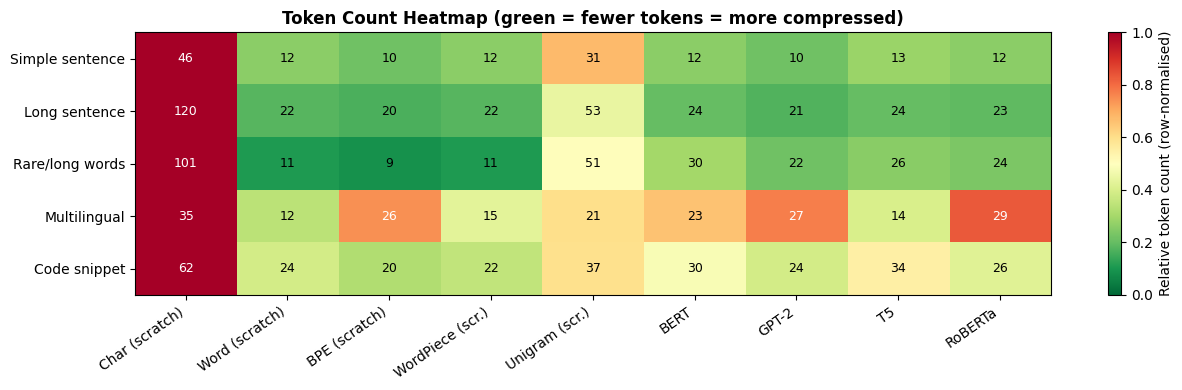

In [31]:
import numpy as np

fig, ax = plt.subplots(figsize=(13, 4))

data = df_compare.values.astype(float)
# Normalise per row so we compare relative efficiency
data_norm = data / data.max(axis=1, keepdims=True)

im = ax.imshow(data_norm, cmap="RdYlGn_r", aspect="auto", vmin=0, vmax=1)

ax.set_xticks(range(len(df_compare.columns)))
ax.set_xticklabels(df_compare.columns, rotation=35, ha="right", fontsize=10)
ax.set_yticks(range(len(df_compare.index)))
ax.set_yticklabels(df_compare.index, fontsize=10)

# Add raw counts as cell labels
for i in range(data.shape[0]):
    for j in range(data.shape[1]):
        ax.text(j, i, str(int(data[i, j])), ha="center", va="center", fontsize=9,
                color="black" if data_norm[i, j] < 0.7 else "white")

ax.set_title("Token Count Heatmap (green = fewer tokens = more compressed)",
             fontsize=12, fontweight="bold")
plt.colorbar(im, ax=ax, label="Relative token count (row-normalised)")
plt.tight_layout()
plt.show()

### Side-by-side segmentation of a single word

In [32]:
target_word = "tokenization"
print(f"How each tokenizer segments: '{target_word}'\n")

seg_results = {
    "Character"   : list(target_word),
    "Word-Level"  : [target_word] if target_word in word_tok.token2id else ["<unk>"],
    "BPE (scr.)" : hf_bpe.tokenize(target_word),
    "WordPiece"  : hf_wp.tokenize(target_word),
    "Unigram"    : hf_unigram.tokenize(target_word),
    "BERT"        : bert_tok.tokenize(target_word),
    "GPT-2"       : gpt2_tok.tokenize(target_word),
    "T5"          : t5_tok.tokenize(target_word),
}

for tok_name, segs in seg_results.items():
    print(f"  {tok_name:<14}: {segs}")

How each tokenizer segments: 'tokenization'

  Character     : ['t', 'o', 'k', 'e', 'n', 'i', 'z', 'a', 't', 'i', 'o', 'n']
  Word-Level    : ['tokenization']
  BPE (scr.)    : ['tokenization']
  WordPiece     : ['tokenization']
  Unigram       : ['▁', 't', 'okeniz', 'ation']
  BERT          : ['token', '##ization']
  GPT-2         : ['token', 'ization']
  T5            : ['▁token', 'ization']


### Token count bar chart for SAMPLE_LONG

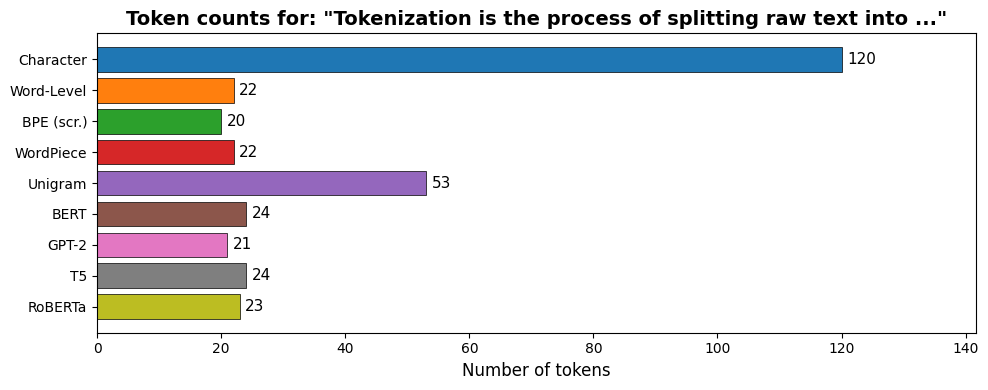

In [33]:
counts_long = {
    "Character" : len(char_tok.encode(SAMPLE_LONG)),
    "Word-Level": len(word_tok.encode(SAMPLE_LONG)),
    "BPE (scr.)": len(hf_bpe.encode(SAMPLE_LONG)),
    "WordPiece" : len(hf_wp.encode(SAMPLE_LONG)),
    "Unigram"   : len(hf_unigram.encode(SAMPLE_LONG)),
    "BERT"      : len(bert_tok.encode(SAMPLE_LONG)),
    "GPT-2"     : len(gpt2_tok.encode(SAMPLE_LONG)),
    "T5"        : len(t5_tok.encode(SAMPLE_LONG)),
    "RoBERTa"   : len(roberta_tok.encode(SAMPLE_LONG)),
}

token_bar_chart(counts_long, f'Token counts for: "{SAMPLE_LONG[:55]}..."')

## Tokenizer Quirks & Gotchas

Every practitioner eventually runs into unexpected tokenizer behaviour. This section catalogues the most common surprises.

### Gotcha #1: Leading space changes tokenization
GPT-2 and RoBERTa use Byte-Level BPE where a space before a word
creates a DIFFERENT token than the same word without a space.

In [34]:
print("Gotcha #1: Leading space affects token IDs in Byte-Level BPE\n")

for tok, name in [(gpt2_tok, "GPT-2"), (roberta_tok, "RoBERTa")]:
    id_no_space = tok.encode("dog")
    id_with_space = tok.encode(" dog")
    print(f"  {name}:")
    print(f"    'dog'  → tokens: {tok.convert_ids_to_tokens(id_no_space)}  IDs: {id_no_space}")
    print(f"    ' dog' → tokens: {tok.convert_ids_to_tokens(id_with_space)} IDs: {id_with_space}")
    print(f"    Same? {id_no_space == id_with_space} ← they differ!")
    print()

print("💡 When encoding individual words, pass add_prefix_space=True to avoid this.")

Gotcha #1: Leading space affects token IDs in Byte-Level BPE

  GPT-2:
    'dog'  → tokens: ['dog']  IDs: [9703]
    ' dog' → tokens: ['Ġdog'] IDs: [3290]
    Same? False ← they differ!

  RoBERTa:
    'dog'  → tokens: ['<s>', 'dog', '</s>']  IDs: [0, 16319, 2]
    ' dog' → tokens: ['<s>', 'Ġdog', '</s>'] IDs: [0, 2335, 2]
    Same? False ← they differ!

💡 When encoding individual words, pass add_prefix_space=True to avoid this.


### Gotcha #2: Numbers are tokenized digit-by-digit (or in unexpected chunks)

In [35]:
print("Gotcha #2: Numbers and arithmetic - tokenization is NOT decimal-aware\n")

number_tests = ["42", "100", "1000", "3.14159", "2024", "1,000,000"]

for num in number_tests:
    bert_toks = bert_tok.tokenize(num)
    gpt2_toks = gpt2_tok.tokenize(" " + num)  # prefix space for GPT-2
    print(f"  {num:<12} BERT={bert_toks}  GPT-2={gpt2_toks}")

print()
print("⚠️  '1000' and '999' have completely different token sequences.")
print("    This is why LLMs struggle at arithmetic - there's no numeric structure in the tokens.")
print("    LLaMA 3 uses a tokenizer that represents individual digits as single tokens to mitigate this.")

Gotcha #2: Numbers and arithmetic - tokenization is NOT decimal-aware

  42           BERT=['42']  GPT-2=['Ġ42']
  100          BERT=['100']  GPT-2=['Ġ100']
  1000         BERT=['1000']  GPT-2=['Ġ1000']
  3.14159      BERT=['3', '.', '141', '##59']  GPT-2=['Ġ3', '.', '14', '159']
  2024         BERT=['202', '##4']  GPT-2=['Ġ2024']
  1,000,000    BERT=['1', ',', '000', ',', '000']  GPT-2=['Ġ1', ',', '000', ',', '000']

⚠️  '1000' and '999' have completely different token sequences.
    This is why LLMs struggle at arithmetic - there's no numeric structure in the tokens.
    LLaMA 3 uses a tokenizer that represents individual digits as single tokens to mitigate this.


### Gotcha #3: Not all tokenizers round-trip cleanly

In [36]:
print("Gotcha #3: encode→decode round-trip fidelity\n")

tricky_texts = [
    "Hello, World!",
    "   leading spaces",
    "trailing spaces   ",
    "line\nnewline",
    "tab\there",
    "café naïve résumé",          # accented characters
]

for tok, name in [(bert_tok, "BERT"), (gpt2_tok, "GPT-2"), (t5_tok, "T5")]:
    print(f"  {name}:")
    for text in tricky_texts:
        ids = tok.encode(text)
        decoded = tok.decode(ids, skip_special_tokens=True)
        match = text.strip() == decoded.strip()
        status = "✅" if match else "⚠️ "
        if not match:
            print(f"    {status} {repr(text)[:30]:<32} → {repr(decoded)[:30]}")
    print()

print("💡 BERT lowercases + strips accents, so it loses case information permanently.")
print("   GPT-2 and T5 preserve most characters via byte-level encoding.")

Gotcha #3: encode→decode round-trip fidelity

  BERT:
    ⚠️  'Hello, World!'                  → 'hello, world!'
    ⚠️  'line\nnewline'                  → 'line newline'
    ⚠️  'tab\there'                      → 'tab here'
    ⚠️  'café naïve résumé'              → 'cafe naive resume'

  GPT-2:

  T5:
    ⚠️  'line\nnewline'                  → 'line newline'
    ⚠️  'tab\there'                      → 'tab here'
    ⚠️  'café naïve résumé'              → 'café nave résumé'

💡 BERT lowercases + strips accents, so it loses case information permanently.
   GPT-2 and T5 preserve most characters via byte-level encoding.


### Gotcha #4: Padding for batched inputs
When processing multiple sentences simultaneously, shorter sequences must be padded to match the longest one.

In [37]:
print("Gotcha #4: Batched encoding with padding and attention masks\n")

batch = [
    "Hi",
    "Hello world",
    "The quick brown fox jumps over the lazy dog",
]

# Without padding: different lengths, cannot stack into a tensor
no_pad = bert_tok(batch)
print("Without padding (IDs only):")
for i, ids in enumerate(no_pad["input_ids"]):
    print(f"  Sentence {i+1} ({len(ids):2d} tokens): {ids}")

print()

# With padding: all sequences padded to max length
padded = bert_tok(batch, padding=True, return_tensors="pt")
print("With padding (padded to max length in batch):")
print(f"  input_ids shape  : {list(padded['input_ids'].shape)}")
print(f"  attention_mask   : tells the model which tokens are real vs padding")
print()
for i in range(len(batch)):
    ids   = padded["input_ids"][i].tolist()
    masks = padded["attention_mask"][i].tolist()
    print(f"  S{i+1} IDs   : {ids}")
    print(f"  S{i+1} Masks : {masks}  (0 = pad, ignore)")
    print()

Gotcha #4: Batched encoding with padding and attention masks

Without padding (IDs only):
  Sentence 1 ( 3 tokens): [101, 7632, 102]
  Sentence 2 ( 4 tokens): [101, 7592, 2088, 102]
  Sentence 3 (11 tokens): [101, 1996, 4248, 2829, 4419, 14523, 2058, 1996, 13971, 3899, 102]

With padding (padded to max length in batch):
  input_ids shape  : [3, 11]
  attention_mask   : tells the model which tokens are real vs padding

  S1 IDs   : [101, 7632, 102, 0, 0, 0, 0, 0, 0, 0, 0]
  S1 Masks : [1, 1, 1, 0, 0, 0, 0, 0, 0, 0, 0]  (0 = pad, ignore)

  S2 IDs   : [101, 7592, 2088, 102, 0, 0, 0, 0, 0, 0, 0]
  S2 Masks : [1, 1, 1, 1, 0, 0, 0, 0, 0, 0, 0]  (0 = pad, ignore)

  S3 IDs   : [101, 1996, 4248, 2829, 4419, 14523, 2058, 1996, 13971, 3899, 102]
  S3 Masks : [1, 1, 1, 1, 1, 1, 1, 1, 1, 1, 1]  (0 = pad, ignore)



### Gotcha #5: Max sequence length truncation
Models have a fixed context window. Inputs that exceed it
must be truncated - and you lose the truncated content!

In [38]:
print("Gotcha #5: Truncation and context window limits\n")

# BERT has a 512-token limit
long_text = SAMPLE_LONG * 20  # artificially very long

no_trunc  = bert_tok(long_text)
truncated = bert_tok(long_text, max_length=20, truncation=True)

print(f"Original token count     : {len(no_trunc['input_ids'])}")
print(f"After truncation (max=20): {len(truncated['input_ids'])}")
print(f"Truncated IDs            : {truncated['input_ids']}")
print(f"Truncated tokens         : {bert_tok.convert_ids_to_tokens(truncated['input_ids'])}")

print()
print("Common model context window sizes:")
limits = [
    ("BERT / DistilBERT", 512),
    ("GPT-2", 1024),
    ("GPT-3", 4096),
    ("T5-small", 512),
    ("LLaMA 2", 4096),
    ("Claude 3.5 Sonnet", 200000),
    ("Gemini 1.5 Pro", 1000000),
]
for model, limit in limits:
    bar = "█" * (limit // 5000)
    print(f"  {model:<22}: {limit:>8,} tokens  {bar}")

Gotcha #5: Truncation and context window limits

Original token count     : 442
After truncation (max=20): 20
Truncated IDs            : [101, 19204, 3989, 2003, 1996, 2832, 1997, 14541, 6315, 3793, 2046, 3760, 3197, 2170, 19204, 2015, 1010, 2029, 15756, 102]
Truncated tokens         : ['[CLS]', 'token', '##ization', 'is', 'the', 'process', 'of', 'splitting', 'raw', 'text', 'into', 'smaller', 'units', 'called', 'token', '##s', ',', 'which', 'neural', '[SEP]']

Common model context window sizes:
  BERT / DistilBERT     :      512 tokens  
  GPT-2                 :    1,024 tokens  
  GPT-3                 :    4,096 tokens  
  T5-small              :      512 tokens  
  LLaMA 2               :    4,096 tokens  
  Claude 3.5 Sonnet     :  200,000 tokens  ████████████████████████████████████████
  Gemini 1.5 Pro        : 1,000,000 tokens  ████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████████

### Gotcha #6: Adding new tokens to a pre-trained tokenizer
When fine-tuning on a domain with novel terminology (e.g. medical, legal, code), you can add tokens to avoid fragmented subword splits.

In [39]:
print("Gotcha #6: Adding domain-specific tokens to a pre-trained tokenizer\n")

# Load a fresh copy for this demo
demo_tok = AutoTokenizer.from_pretrained("bert-base-uncased")

domain_word = "sclerotherapy"   # medical term
before = demo_tok.tokenize(domain_word)
print(f"Before adding token: '{domain_word}' → {before}")

# Add the token
num_added = demo_tok.add_tokens(["sclerotherapy", "angioplasty", "endoscopy"])
after = demo_tok.tokenize(domain_word)
print(f"After adding token : '{domain_word}' → {after}")
print(f"New vocab size     : {len(demo_tok)}  (was {len(demo_tok) - num_added})")

print()
print("⚠️  IMPORTANT: After add_tokens(), you MUST also call:")
print("   model.resize_token_embeddings(len(tokenizer))")
print("   to expand the embedding matrix in your model!")
print("   The new embeddings are randomly initialised and will be learned during fine-tuning.")

Gotcha #6: Adding domain-specific tokens to a pre-trained tokenizer

Before adding token: 'sclerotherapy' → ['sc', '##ler', '##oth', '##era', '##py']
After adding token : 'sclerotherapy' → ['sclerotherapy']
New vocab size     : 30525  (was 30522)

⚠️  IMPORTANT: After add_tokens(), you MUST also call:
   model.resize_token_embeddings(len(tokenizer))
   to expand the embedding matrix in your model!
   The new embeddings are randomly initialised and will be learned during fine-tuning.


### Gotcha #7: Same word → different IDs in different models
NEVER hard-code token IDs when switching between models!

In [40]:
print("Gotcha #7: Token IDs are NOT portable across models\n")

word = "transformer"
print(f"Token IDs for '{word}' in each tokenizer:")
print()
for name, tok in models.items():
    ids  = tok.encode(word, add_special_tokens=False)
    toks = tok.convert_ids_to_tokens(ids)
    print(f"  {name:<10}: IDs={ids}  →  tokens={toks}")

print()
print("💡 Always use tokenizer.encode() / tokenizer.convert_tokens_to_ids()")
print("   rather than assuming token IDs transfer between tokenizers.")

Gotcha #7: Token IDs are NOT portable across models

Token IDs for 'transformer' in each tokenizer:

  BERT      : IDs=[10938, 2121]  →  tokens=['transform', '##er']
  GPT-2     : IDs=[7645, 16354]  →  tokens=['trans', 'former']
  T5        : IDs=[19903]  →  tokens=['▁transformer']
  RoBERTa   : IDs=[9981, 22098]  →  tokens=['trans', 'former']

💡 Always use tokenizer.encode() / tokenizer.convert_tokens_to_ids()
   rather than assuming token IDs transfer between tokenizers.


### Gotcha #8: Chat / instruction tokenizers use apply_chat_template() - not just encode()
Modern instruction-tuned models (LLaMA-3-Instruct, Mistral-Instruct)
expect a specific conversation format with role markers.

In [41]:
print("Gotcha #8: Chat models need apply_chat_template()\n")

# We'll demonstrate with a generic chat template pattern
# (no auth required - just showing the concept)

chat_messages = [
    {"role": "system",    "content": "You are a helpful AI assistant."},
    {"role": "user",      "content": "Explain tokenization in one sentence."},
    {"role": "assistant", "content": "Tokenization splits text into smaller units called tokens."},
    {"role": "user",      "content": "What is BPE?"},
]

# Simulate what a chat template does
def simple_chat_template(messages):
    """Mimics the Llama-3 Instruct chat template format."""
    rendered = "<|begin_of_text|>"
    for msg in messages:
        rendered += f"<|start_header_id|>{msg['role']}<|end_header_id|>\n\n"
        rendered += msg["content"]
        rendered += "<|eot_id|>"
    rendered += "<|start_header_id|>assistant<|end_header_id|>\n\n"
    return rendered

formatted = simple_chat_template(chat_messages)
print("Formatted chat string (Llama-3 Instruct format):")
print("-" * 55)
print(formatted)
print("-" * 55)
print()
print("The entire formatted string is then tokenized as a flat sequence.")
print("Without apply_chat_template(), the model will not follow instructions properly.")

Gotcha #8: Chat models need apply_chat_template()

Formatted chat string (Llama-3 Instruct format):
-------------------------------------------------------
<|begin_of_text|><|start_header_id|>system<|end_header_id|>

You are a helpful AI assistant.<|eot_id|><|start_header_id|>user<|end_header_id|>

Explain tokenization in one sentence.<|eot_id|><|start_header_id|>assistant<|end_header_id|>

Tokenization splits text into smaller units called tokens.<|eot_id|><|start_header_id|>user<|end_header_id|>

What is BPE?<|eot_id|><|start_header_id|>assistant<|end_header_id|>


-------------------------------------------------------

The entire formatted string is then tokenized as a flat sequence.
Without apply_chat_template(), the model will not follow instructions properly.


# Final summary and decision guide

In [43]:
print("""
╔══════════════════════════════════════════════════════════════════════╗
║         TOKENIZER SELECTION CHEAT SHEET                              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  SITUATION                          RECOMMENDED APPROACH             ║
║  ─────────────────────────────────  ──────────────────────────────   ║
║  Fine-tuning BERT / DistilBERT      AutoTokenizer('bert-base-*')     ║
║  Fine-tuning GPT-2 / GPT-J          AutoTokenizer('gpt2')            ║
║  Fine-tuning T5 / mT5               AutoTokenizer('t5-*')            ║
║  Fine-tuning LLaMA 2/3              AutoTokenizer('meta-llama/..')   ║
║  Training from scratch (English)    BPE or WordPiece, 30k-50k        ║
║  Training from scratch (multilang)  SentencePiece Unigram            ║
║  Character model / research          CharacterTokenizer (custom)     ║
║  Tiny custom domain vocab            WordLevel (HF tokenizers)       ║
║                                                                      ║
║  GOLDEN RULES                                                        ║
║  1. Always use the tokenizer paired with the checkpoint.             ║
║  2. Never hard-code token IDs - use convert_tokens_to_ids().         ║
║  3. For chat models, use apply_chat_template().                      ║
║  4. After add_tokens(), call model.resize_token_embeddings().        ║
║  5. Always check attention_mask when batching.                       ║
║                                                                      ║
╚══════════════════════════════════════════════════════════════════════╝
""")

print("📖 Further reading:")
print("   • Sennrich et al. (2016) - BPE paper: https://arxiv.org/abs/1508.07909")
print("   • Kudo & Richardson (2018) - SentencePiece: https://arxiv.org/abs/1808.06226")
print("   • Kudo (2018) - Unigram LM: https://arxiv.org/abs/1804.10959")
print("   • HuggingFace Tokenizers docs: https://huggingface.co/docs/tokenizers")
print("   • HuggingFace Tokenizer Summary: https://huggingface.co/docs/transformers/tokenizer_summary")


╔══════════════════════════════════════════════════════════════════════╗
║         TOKENIZER SELECTION CHEAT SHEET                              ║
╠══════════════════════════════════════════════════════════════════════╣
║                                                                      ║
║  SITUATION                          RECOMMENDED APPROACH             ║
║  ─────────────────────────────────  ──────────────────────────────   ║
║  Fine-tuning BERT / DistilBERT      AutoTokenizer('bert-base-*')     ║
║  Fine-tuning GPT-2 / GPT-J          AutoTokenizer('gpt2')            ║
║  Fine-tuning T5 / mT5               AutoTokenizer('t5-*')            ║
║  Fine-tuning LLaMA 2/3              AutoTokenizer('meta-llama/..')   ║
║  Training from scratch (English)    BPE or WordPiece, 30k-50k        ║
║  Training from scratch (multilang)  SentencePiece Unigram            ║
║  Character model / research          CharacterTokenizer (custom)     ║
║  Tiny custom domain vocab            WordLevel (